# Sentence Transformer Applications Demo

This notebook demonstrates practical applications of Sentence Transformers:

- text similarity with cosine similarity
- semantic search beyond keyword matching
- a retrieval-based FAQ chatbot
- text clustering by meaning
- text classification using embeddings as features
- recommendation systems based on description similarity
- paraphrase detection
- multilingual semantic search

The examples use small in-memory datasets so the ideas remain visible. The first run may take a few minutes if the multilingual model must be downloaded.


## 0. Setup

We use `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` for every example. It maps sentences from many languages into the same 384-dimensional semantic vector space.

Normalized embeddings let us compute cosine similarity with a simple dot product:

$$
\operatorname{cosine}(a,b)=\frac{a \cdot b}{\|a\|\|b\|}
$$


In [1]:
import os
import warnings

# Giảm log TensorFlow để output notebook chỉ tập trung vào kết quả demo.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
# Tắt cảnh báo song song của tokenizer khi notebook chạy trong Jupyter kernel.
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Ẩn các FutureWarning từ thư viện để phần trình bày gọn hơn.
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Chọn model đa ngôn ngữ để dùng chung cho cả văn bản tiếng Anh và các ngôn ngữ khác.
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# Tải mô hình đa ngôn ngữ; lần chạy đầu có thể mất thời gian nếu model chưa có trong cache.
model = SentenceTransformer(MODEL_NAME)


def embed_texts(texts):
    """Encode one string or a list of strings into normalized embeddings.

    Parameters:
        texts: A string or a list of strings.

    Returns:
        A NumPy vector for one string or a matrix for a list of strings.
    """
    # Ghi nhận input là một chuỗi hay một danh sách để trả kết quả đúng kiểu ở cuối hàm.
    single_text = isinstance(texts, str)
    # Model luôn nhận danh sách, nên chuỗi đơn cần được bọc thành list một phần tử.
    if single_text:
        texts = [texts]

    # normalize_embeddings=True giúp tích vô hướng bằng cosine similarity.
    embeddings = model.encode(
        texts,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    # Nếu input ban đầu là chuỗi đơn thì trả một vector; nếu là list thì trả cả ma trận.
    return embeddings[0] if single_text else embeddings


def cosine_score(text_a, text_b):
    """Compute cosine similarity between two texts.

    Parameters:
        text_a: First text.
        text_b: Second text.

    Returns:
        Cosine similarity as a float.
    """
    # Mã hóa văn bản thứ nhất thành vector ngữ nghĩa đã chuẩn hóa.
    vector_a = embed_texts(text_a)
    # Mã hóa văn bản thứ hai trong cùng không gian embedding.
    vector_b = embed_texts(text_b)

    # Hai vector đã được chuẩn hóa, nên chỉ cần tính tích vô hướng.
    return float(vector_a @ vector_b)


def rank_by_similarity(query, items, item_embeddings, top_k=5):
    """Rank indexed items by semantic similarity to a query.

    Parameters:
        query: Query text.
        items: Item dictionaries containing display fields.
        item_embeddings: Precomputed normalized item embeddings.
        top_k: Number of results to return.

    Returns:
        A list of dictionaries with rank, score, and item fields.
    """
    # Mã hóa truy vấn một lần trước khi so sánh với toàn bộ chỉ mục.
    query_embedding = embed_texts(query)

    # So sánh query với toàn bộ item trong một phép nhân ma trận.
    scores = item_embeddings @ query_embedding
    # Sắp xếp chỉ số theo điểm giảm dần và chỉ giữ top_k kết quả tốt nhất.
    ranked_indices = np.argsort(scores)[::-1][:top_k]
    # Tạo danh sách để lưu kết quả đã xếp hạng cùng metadata gốc.
    results = []
    # Duyệt các chỉ số đã xếp hạng và đánh số thứ tự bắt đầu từ 1.
    for rank, index in enumerate(ranked_indices, start=1):
        # Ghép rank, score và các trường của item thành một dictionary kết quả.
        results.append({"rank": rank, "score": float(scores[index]), **items[int(index)]})
    # Trả danh sách đã sắp xếp để các ứng dụng phía sau có thể tái sử dụng.
    return results


print("Model loaded:", MODEL_NAME)
print("Embedding dimension:", model.get_sentence_embedding_dimension())


Model loaded: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Embedding dimension: 384


## 1. Text Similarity

Sentence embeddings represent meaning rather than exact word overlap. Cosine similarity can therefore compare:

- two sentences
- two paragraphs
- two whole documents

Scores close to `1` indicate similar directions in the embedding space. The useful decision threshold depends on the model, language, and task.


In [2]:
# Chuẩn bị các cặp câu có quan hệ gần nghĩa và không liên quan để so sánh.
sentence_pairs = [
    (
        "A student is learning machine learning.",
        "A learner is studying artificial intelligence.",
        "related",
    ),
    (
        "The university library closes at nine o'clock.",
        "The campus book center is open until 9 PM.",
        "related",
    ),
    (
        "The football team won the championship.",
        "The database server needs more memory.",
        "unrelated",
    ),
    (
        "I cannot sign in to my account.",
        "I forgot my password and cannot log in.",
        "related",
    ),
]

# Tạo danh sách lưu điểm similarity và nhãn kỳ vọng của từng cặp.
rows = []
# Duyệt lần lượt từng cặp câu trong bộ dữ liệu minh họa.
for text_a, text_b, expected_relation in sentence_pairs:
    # Mỗi cặp câu được mã hóa riêng và so sánh bằng cosine similarity.
    # Lưu câu gốc, quan hệ kỳ vọng và cosine similarity vào một dòng kết quả.
    rows.append(
        {
            "text A": text_a,
            "text B": text_b,
            "expected": expected_relation,
            "cosine similarity": round(cosine_score(text_a, text_b), 3),
        }
    )

# Chuyển danh sách dictionary thành bảng để dễ so sánh các điểm số.
pd.DataFrame(rows)


,text A,text B,expected,cosine similarity
0,A student is learning machine learning.,A learner is studying artificial intelligence.,related,0.769
1,The university library closes at nine o'clock.,The campus book center is open until 9 PM.,related,0.597
2,The football team won the championship.,The database server needs more memory.,unrelated,0.102
3,I cannot sign in to my account.,I forgot my password and cannot log in.,related,0.736


In [3]:
# Tạo bốn tài liệu thuộc các chủ đề khác nhau để lập ma trận similarity.
documents = {
    "AI course": (
        "This course introduces machine learning, neural networks, and intelligent systems. "
        "Students build models that learn from data."
    ),
    "Data science course": (
        "This course teaches data analysis, predictive modeling, and visualization. "
        "Students use statistical and machine learning tools."
    ),
    "Marketing course": (
        "This course covers customer behavior, branding, digital campaigns, and market strategy. "
        "Students design communication plans for products."
    ),
    "Sports report": (
        "The basketball team trained for the final tournament. "
        "Players practiced defense and shooting every afternoon."
    ),
}

# Mã hóa toàn bộ tài liệu một lần để tạo ma trận similarity cặp đôi.
document_embeddings = embed_texts(list(documents.values()))
# Nhân ma trận embedding với chuyển vị để tính similarity cho mọi cặp tài liệu.
document_similarity = document_embeddings @ document_embeddings.T

# Đưa ma trận similarity vào DataFrame với nhãn hàng và cột là tên tài liệu.
pd.DataFrame(
    np.round(document_similarity, 3),
    index=documents.keys(),
    columns=documents.keys(),
)


,AI course,Data science course,Marketing course,Sports report
AI course,1.000,0.839,0.535,0.084
Data science course,0.839,1.000,0.558,0.137
Marketing course,0.535,0.558,1.000,0.062
Sports report,0.084,0.137,0.062,1.000


## 2. Semantic Search

Keyword search looks for shared words. Semantic search retrieves documents that express the same idea, even when the query uses different vocabulary.

The workflow is:

1. encode the document collection once
2. encode a user query
3. compute cosine similarity to every document
4. return the highest-scoring documents


In [4]:
# Khai báo kho tri thức nhỏ; mỗi tài liệu có mã, tiêu đề và nội dung.
knowledge_base = [
    {
        "id": "KB-101",
        "title": "Resetting an account password",
        "text": "Use the account security page to create a new password after verifying your email address.",
    },
    {
        "id": "KB-102",
        "title": "Paying university fees",
        "text": "Tuition invoices can be paid online by card or bank transfer before the payment deadline.",
    },
    {
        "id": "KB-103",
        "title": "Borrowing library materials",
        "text": "Students can check out books and journals at the library desk with a valid student ID.",
    },
    {
        "id": "KB-104",
        "title": "Registering for classes",
        "text": "Course enrollment is available through the academic portal during the registration period.",
    },
    {
        "id": "KB-105",
        "title": "Joining student clubs",
        "text": "Contact student affairs or attend club day to join sports, music, and volunteer organizations.",
    },
    {
        "id": "KB-106",
        "title": "Requesting an academic transcript",
        "text": "Official transcripts can be ordered through the registrar and delivered electronically.",
    },
]

# Chỉ mục embedding được tính trước và có thể tái sử dụng cho nhiều truy vấn.
knowledge_embeddings = embed_texts([item["title"] + ". " + item["text"] for item in knowledge_base])


def semantic_search(query, top_k=3):
    """Search the knowledge base by meaning.

    Parameters:
        query: Natural-language search query.
        top_k: Number of documents to return.

    Returns:
        A DataFrame containing ranked search results.
    """
    # Gọi hàm xếp hạng dùng chung để tìm các tài liệu gần nghĩa nhất với query.
    results = rank_by_similarity(query, knowledge_base, knowledge_embeddings, top_k=top_k)
    # Chỉ giữ các cột cần thiết và trả về dưới dạng bảng kết quả tìm kiếm.
    return pd.DataFrame(results)[["rank", "score", "id", "title", "text"]]


# Chạy một truy vấn không dùng đúng từ khóa "reset password" để minh họa semantic search.
semantic_search("I forgot my login credentials and need access again", top_k=3)


,rank,score,id,title,text
0,1,0.553323,KB-101,Resetting an account password,Use the account security page to create a new ...
1,2,0.167264,KB-104,Registering for classes,Course enrollment is available through the aca...
2,3,0.159311,KB-105,Joining student clubs,Contact student affairs or attend club day to ...


In [5]:
# Chuẩn bị nhiều cách diễn đạt tự nhiên cho các nhu cầu tìm kiếm khác nhau.
search_queries = [
    "How can I order an official academic transcript of my grades?",
    "I want to become a member of the university basketball group.",
    "How can I settle my semester bill?",
]

# Chạy từng truy vấn trên cùng chỉ mục embedding đã tính trước.
for query in search_queries:
    print("=" * 90)
    print("Query:", query)
    # Hiển thị hai tài liệu gần nghĩa nhất cho truy vấn hiện tại.
    display(semantic_search(query, top_k=2))


Query: How can I order an official academic transcript of my grades?


,rank,score,id,title,text
0,1,0.713936,KB-106,Requesting an academic transcript,Official transcripts can be ordered through th...
1,2,0.372067,KB-104,Registering for classes,Course enrollment is available through the aca...


Query: I want to become a member of the university basketball group.


,rank,score,id,title,text
0,1,0.505761,KB-105,Joining student clubs,Contact student affairs or attend club day to ...
1,2,0.319009,KB-104,Registering for classes,Course enrollment is available through the aca...


Query: How can I settle my semester bill?


,rank,score,id,title,text
0,1,0.395096,KB-102,Paying university fees,Tuition invoices can be paid online by card or...
1,2,0.215247,KB-103,Borrowing library materials,Students can check out books and journals at t...


## 3. Retrieval-Based FAQ Chatbot

A retrieval chatbot does not generate an answer from scratch. It finds the nearest stored FAQ question and returns its associated answer.

This approach is:

- simple and interpretable
- fast for small knowledge bases
- safer when answers must come from approved content
- limited when no stored question is sufficiently similar


In [6]:
# Tạo tập FAQ đã được kiểm duyệt gồm câu hỏi mẫu và câu trả lời tương ứng.
faq_pairs = [
    {
        "question": "How can I reset my password?",
        "answer": "Open Account Security, choose Reset Password, and verify the link sent to your email.",
    },
    {
        "question": "How do I pay tuition fees?",
        "answer": "Open the Finance section of the student portal and choose card or bank transfer.",
    },
    {
        "question": "Where can I borrow textbooks?",
        "answer": "Bring your student ID to the university library circulation desk.",
    },
    {
        "question": "How do I register for a course?",
        "answer": "Use the academic portal during the announced registration period.",
    },
    {
        "question": "How can I contact my academic advisor?",
        "answer": "Advisor contact details and appointment times are listed in the advising portal.",
    },
    {
        "question": "How do I request an official transcript?",
        "answer": "Submit a transcript request through the registrar's online service.",
    },
]

# Câu hỏi mẫu được mã hóa trước, giống như tạo chỉ mục semantic search.
faq_embeddings = embed_texts([pair["question"] for pair in faq_pairs])


def answer_faq(user_question, threshold=0.43, top_k=3):
    """Retrieve the nearest FAQ and return its approved answer.

    Parameters:
        user_question: Question entered by the user.
        threshold: Minimum score required to return an answer.
        top_k: Number of nearest FAQ questions to include for inspection.

    Returns:
        A dictionary with the answer, best match, score, and top matches.
    """
    # Mã hóa câu hỏi người dùng để đặt nó vào cùng không gian với FAQ.
    user_embedding = embed_texts(user_question)

    # Xếp hạng tất cả FAQ theo similarity với câu hỏi người dùng.
    scores = faq_embeddings @ user_embedding
    # Sắp xếp toàn bộ FAQ theo similarity giảm dần.
    ranked_indices = np.argsort(scores)[::-1]
    # Lấy chỉ số của FAQ có điểm cao nhất làm ứng viên trả lời.
    best_index = int(ranked_indices[0])
    # Chuyển điểm tốt nhất về float Python để dễ hiển thị và serialize.
    best_score = float(scores[best_index])

    # Lưu thêm một số câu hỏi gần nhất để giải thích quyết định của chatbot.
    top_matches = [
        {
            "question": faq_pairs[int(index)]["question"],
            "score": float(scores[int(index)]),
        }
        for index in ranked_indices[:top_k]
    ]

    # Nếu similarity thấp hơn ngưỡng, từ chối trả lời để tránh suy đoán ngoài dữ liệu.
    if best_score < threshold:
        answer = "I do not have a sufficiently confident answer in the FAQ knowledge base."
    else:
        # Khi đủ tự tin, trả câu trả lời đã được ghép với FAQ tốt nhất.
        answer = faq_pairs[best_index]["answer"]

    # Trả cả câu trả lời, câu hỏi được khớp, điểm số và top matches để kiểm tra.
    return {
        "user_question": user_question,
        "matched_question": faq_pairs[best_index]["question"],
        "score": best_score,
        "answer": answer,
        "top_matches": top_matches,
    }


In [7]:
# Chuẩn bị ba câu hỏi trong miền và một câu hỏi ngoài miền kiến thức FAQ.
chat_questions = [
    "I cannot remember my login password.",
    "Who should I talk to about choosing next semester's classes?",
    "Where can I obtain an official transcript of my grades?",
    "What will the weather be on Mars tomorrow?",
]

# Gửi từng câu hỏi qua chatbot để quan sát cả trường hợp trả lời và từ chối.
for question in chat_questions:
    # Dùng ngưỡng đã chọn để lấy kết quả retrieval và quyết định có trả lời hay không.
    result = answer_faq(question, threshold=0.43)
    print("=" * 90)
    print("User:", result["user_question"])
    print("Matched FAQ:", result["matched_question"])
    print("Similarity:", round(result["score"], 3))
    print("Bot:", result["answer"])


User: I cannot remember my login password.
Matched FAQ: How can I reset my password?
Similarity: 0.781
Bot: Open Account Security, choose Reset Password, and verify the link sent to your email.
User: Who should I talk to about choosing next semester's classes?
Matched FAQ: How can I contact my academic advisor?
Similarity: 0.456
Bot: Advisor contact details and appointment times are listed in the advising portal.
User: Where can I obtain an official transcript of my grades?
Matched FAQ: How do I request an official transcript?
Similarity: 0.645
Bot: Submit a transcript request through the registrar's online service.


User: What will the weather be on Mars tomorrow?
Matched FAQ: How do I register for a course?
Similarity: 0.011
Bot: I do not have a sufficiently confident answer in the FAQ knowledge base.


In [8]:
# Chọn một câu hỏi để phân tích chi tiết các FAQ gần nhất.
inspection_question = "I need help paying my university bill."
# Yêu cầu chatbot lưu ba kết quả đầu thay vì chỉ câu tốt nhất.
inspection_result = answer_faq(inspection_question, top_k=3)

print("Question:", inspection_question)
# Hiển thị top matches để thấy mô hình xếp hạng câu hỏi FAQ như thế nào.
pd.DataFrame(inspection_result["top_matches"])


Question: I need help paying my university bill.


,question,score
0,How do I pay tuition fees?,0.682462
1,How can I contact my academic advisor?,0.396638
2,Where can I borrow textbooks?,0.392117


## 4. Text Clustering

Clustering groups texts without labeled training examples. Documents with nearby embeddings should share a topic or intent.

In this example:

- Sentence Transformer creates semantic features
- K-means assigns each item to one of three clusters
- PCA reduces 384 dimensions to two dimensions for visualization


In [9]:
# Tạo 12 bản tin thuộc ba chủ đề để kiểm tra khả năng phân cụm theo ý nghĩa.
news_items = [
    {"text": "The football club signed a new striker before the national tournament.", "topic": "sports"},
    {"text": "The basketball team won after scoring in the final seconds.", "topic": "sports"},
    {"text": "The tennis player advanced to the championship match.", "topic": "sports"},
    {"text": "The coach changed the defensive strategy for the next game.", "topic": "sports"},
    {"text": "A software company released a faster artificial intelligence processor.", "topic": "technology"},
    {"text": "Researchers introduced a new model for understanding images and text.", "topic": "technology"},
    {"text": "The mobile application added stronger privacy and security controls.", "topic": "technology"},
    {"text": "Cloud providers announced new tools for training machine learning systems.", "topic": "technology"},
    {"text": "The central bank increased interest rates to control inflation.", "topic": "finance"},
    {"text": "Shares rose after the company reported higher quarterly profits.", "topic": "finance"},
    {"text": "Investors moved money into bonds during a volatile trading session.", "topic": "finance"},
    {"text": "The government published its economic growth forecast for next year.", "topic": "finance"},
]

# Embedding thay thế vector từ khóa, nên văn bản cùng ý nghĩa có thể gần nhau dù khác từ.
news_embeddings = embed_texts([item["text"] for item in news_items])

# Khởi tạo K-means với ba cụm và seed cố định để kết quả có thể lặp lại.
kmeans = KMeans(n_clusters=3, random_state=26, n_init=20)
# Học tâm cụm trên embedding và gán cluster ID cho từng bản tin.
cluster_ids = kmeans.fit_predict(news_embeddings)

# Chuyển dữ liệu gốc thành bảng để ghép với cluster dự đoán.
cluster_table = pd.DataFrame(news_items)
# Chèn cluster ID vào cột đầu để dễ quan sát kết quả.
cluster_table.insert(0, "cluster", cluster_ids)
# Sắp xếp theo cụm và chủ đề thật để kiểm tra mức độ đồng nhất của từng cụm.
cluster_table.sort_values(["cluster", "topic"])


,cluster,text,topic
0,0,The football club signed a new striker before ...,sports
1,0,The basketball team won after scoring in the f...,sports
2,0,The tennis player advanced to the championship...,sports
3,0,The coach changed the defensive strategy for t...,sports
4,1,A software company released a faster artificia...,technology
5,1,Researchers introduced a new model for underst...,technology
6,1,The mobile application added stronger privacy ...,technology
7,1,Cloud providers announced new tools for traini...,technology
8,2,The central bank increased interest rates to c...,finance
9,2,Shares rose after the company reported higher ...,finance


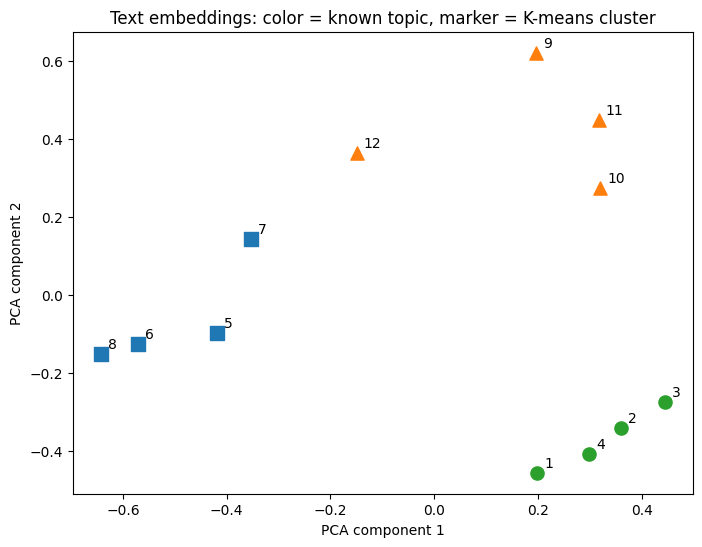

topic,finance,sports,technology
cluster,,,
0,0,4,0
1,0,0,4
2,4,0,0


In [10]:
# PCA chỉ phục vụ trực quan hóa; K-means vẫn học trên embedding 384 chiều đầy đủ.
# Khởi tạo PCA để nén embedding xuống hai chiều cho mục đích vẽ biểu đồ.
pca = PCA(n_components=2, random_state=26)
# Học phép chiếu PCA và biến mỗi embedding thành một điểm 2D.
points_2d = pca.fit_transform(news_embeddings)

# Tạo vùng vẽ có kích thước đủ lớn để hiển thị nhãn điểm.
fig, ax = plt.subplots(figsize=(8, 6))
# Ánh xạ chủ đề thật sang màu để so sánh với cluster dự đoán.
colors = {"sports": "tab:green", "technology": "tab:blue", "finance": "tab:orange"}
# Dùng hình marker khác nhau để biểu diễn ba cluster của K-means.
markers = ["o", "s", "^"]

# Duyệt từng bản tin để vẽ điểm embedding tương ứng.
for index, item in enumerate(news_items):
    # Vẽ điểm với màu của topic thật và marker của cluster dự đoán.
    ax.scatter(
        points_2d[index, 0],
        points_2d[index, 1],
        color=colors[item["topic"]],
        marker=markers[int(cluster_ids[index])],
        s=90,
    )
    # Gắn số thứ tự để đối chiếu điểm trên biểu đồ với bảng dữ liệu.
    ax.annotate(str(index + 1), points_2d[index], xytext=(5, 4), textcoords="offset points")

ax.set_title("Text embeddings: color = known topic, marker = K-means cluster")
ax.set_xlabel("PCA component 1")
ax.set_ylabel("PCA component 2")
plt.show()

# Tạo bảng chéo để đếm mỗi topic thật xuất hiện bao nhiêu lần trong từng cluster.
pd.crosstab(cluster_table["cluster"], cluster_table["topic"])


## 5. Text Classification

Sentence embeddings can be used as numerical features for a conventional supervised classifier.

The pipeline is:

1. encode labeled training texts
2. train a classifier such as logistic regression
3. encode new texts with the same Sentence Transformer
4. predict topic, sentiment, or user intent


In [11]:
# Tạo dữ liệu huấn luyện có nhãn cho ba loại intent hỗ trợ khách hàng.
training_examples = [
    ("I was charged twice for the same subscription.", "billing"),
    ("Where can I download my invoice?", "billing"),
    ("How can I update my payment method?", "billing"),
    ("I need a refund for the last transaction.", "billing"),
    ("The amount on my bill is incorrect.", "billing"),
    ("When is my next payment due?", "billing"),
    ("The mobile application crashes when I open it.", "technical_support"),
    ("The website is loading very slowly.", "technical_support"),
    ("I cannot connect to the server.", "technical_support"),
    ("File upload fails with an error message.", "technical_support"),
    ("The screen freezes after the latest update.", "technical_support"),
    ("The page displays error code 503.", "technical_support"),
    ("How do I reset my account password?", "account_management"),
    ("I want to change the email address on my profile.", "account_management"),
    ("Please delete my account permanently.", "account_management"),
    ("How can I enable two-factor authentication?", "account_management"),
    ("I cannot sign in to my user account.", "account_management"),
    ("Where can I edit my profile information?", "account_management"),
]

# Tạo bộ kiểm thử với cách diễn đạt khác dữ liệu huấn luyện.
test_examples = [
    ("The service billed my card two times.", "billing"),
    ("Please send me a receipt for my payment.", "billing"),
    ("The app closes immediately after launch.", "technical_support"),
    ("Why does the site keep showing a connection error?", "technical_support"),
    ("I need to use a different email for my account.", "account_management"),
    ("Help me create a new login password.", "account_management"),
]

# Embedding là đặc trưng đầu vào; nhãn intent là target cho supervised learning.
# Mã hóa toàn bộ câu huấn luyện thành ma trận đặc trưng embedding.
x_train = embed_texts([text for text, _ in training_examples])
# Tách nhãn intent huấn luyện thành mảng target.
y_train = np.array([label for _, label in training_examples])
# Mã hóa câu kiểm thử bằng đúng Sentence Transformer đã dùng cho train.
x_test = embed_texts([text for text, _ in test_examples])
# Tách nhãn thật của bộ kiểm thử để đánh giá mô hình.
y_test = np.array([label for _, label in test_examples])

# Khởi tạo Logistic Regression làm bộ phân loại trên embedding.
intent_classifier = LogisticRegression(max_iter=1000, random_state=26)
# Huấn luyện classifier học ranh giới giữa ba intent trong không gian vector.
intent_classifier.fit(x_train, y_train)

# Dự đoán intent cho từng câu kiểm thử.
predictions = intent_classifier.predict(x_test)
# Lấy xác suất lớp để minh họa mức độ tự tin của dự đoán.
probabilities = intent_classifier.predict_proba(x_test)

# Tạo danh sách để ghép văn bản, nhãn thật, nhãn dự đoán và confidence.
prediction_rows = []
# Duyệt từng mẫu kiểm thử và lấy thông tin dự đoán ở cùng vị trí.
for index, (text, expected) in enumerate(test_examples):
    # Lưu một dòng kết quả có đầy đủ thông tin phục vụ phân tích.
    prediction_rows.append(
        {
            "text": text,
            "expected": expected,
            "predicted": predictions[index],
            "confidence": round(float(probabilities[index].max()), 3),
        }
    )

# Chuyển kết quả dự đoán thành bảng dễ đọc.
pd.DataFrame(prediction_rows)


,text,expected,predicted,confidence
0,The service billed my card two times.,billing,billing,0.546
1,Please send me a receipt for my payment.,billing,billing,0.634
2,The app closes immediately after launch.,technical_support,technical_support,0.528
3,Why does the site keep showing a connection er...,technical_support,technical_support,0.571
4,I need to use a different email for my account.,account_management,account_management,0.510
5,Help me create a new login password.,account_management,account_management,0.619


In [12]:
# Tính tỉ lệ tổng thể các dự đoán đúng trên bộ kiểm thử.
accuracy = accuracy_score(y_test, predictions)
# Tính precision, recall và F1 cho từng lớp dưới dạng dictionary.
report = classification_report(y_test, predictions, output_dict=True, zero_division=0)

print("Accuracy:", round(float(accuracy), 3))
# Chuyển báo cáo thành bảng, chuyển vị và làm tròn để dễ đọc.
display(pd.DataFrame(report).T.round(3))

# Sắp xếp danh sách nhãn để hàng và cột confusion matrix có thứ tự ổn định.
labels = sorted(set(y_train))
# Đưa confusion matrix vào DataFrame với nhãn hàng/cột rõ ràng.
pd.DataFrame(
    confusion_matrix(y_test, predictions, labels=labels),
    index=[f"actual: {label}" for label in labels],
    columns=[f"predicted: {label}" for label in labels],
)


Accuracy: 1.0


,precision,recall,f1-score,support
account_management,1.0,1.0,1.0,2.0
billing,1.0,1.0,1.0,2.0
technical_support,1.0,1.0,1.0,2.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,6.0
weighted avg,1.0,1.0,1.0,6.0


,predicted: account_management,predicted: billing,predicted: technical_support
actual: account_management,2,0,0
actual: billing,0,2,0
actual: technical_support,0,0,2


## 6. Recommendation System

Content-based recommendation uses semantic similarity between:

- a user profile and item descriptions
- one selected item and other items

Unlike collaborative filtering, this approach does not require behavior from many users. It can recommend new items as soon as their descriptions are available.


In [13]:
# Khai báo catalog khóa học gồm mã, tiêu đề và mô tả nội dung.
courses = [
    {
        "id": "C01",
        "title": "Python Programming for Beginners",
        "description": "Learn Python syntax, functions, data structures, and practical programming skills.",
    },
    {
        "id": "C02",
        "title": "Data Analytics with Excel",
        "description": "Analyze business data with spreadsheets, pivot tables, dashboards, and formulas.",
    },
    {
        "id": "C03",
        "title": "Natural Language Processing with Transformers",
        "description": "Build systems for text embeddings, semantic search, classification, and question answering.",
    },
    {
        "id": "C04",
        "title": "Computer Vision with Deep Learning",
        "description": "Use neural networks for image classification, object detection, and visual applications.",
    },
    {
        "id": "C05",
        "title": "Digital Marketing Fundamentals",
        "description": "Plan campaigns, analyze audiences, manage social media, and improve online branding.",
    },
    {
        "id": "C06",
        "title": "Cloud Computing Essentials",
        "description": "Deploy scalable applications using cloud infrastructure, containers, and managed services.",
    },
    {
        "id": "C07",
        "title": "Machine Learning Foundations",
        "description": "Train predictive models for classification, regression, clustering, and recommendation.",
    },
]

# Nối title và description để embedding biểu diễn đầy đủ hơn nội dung khóa học.
course_embeddings = embed_texts([course["title"] + ". " + course["description"] for course in courses])


def recommend_for_profile(profile, top_k=4):
    """Recommend courses for a natural-language learner profile.

    Parameters:
        profile: Description of learner interests and goals.
        top_k: Number of courses to recommend.

    Returns:
        A DataFrame of ranked recommendations.
    """
    # So sánh hồ sơ người học với tất cả khóa học và lấy top_k kết quả.
    results = rank_by_similarity(profile, courses, course_embeddings, top_k=top_k)
    # Trả bảng recommendation chỉ gồm các trường cần hiển thị.
    return pd.DataFrame(results)[["rank", "score", "id", "title", "description"]]


# Mô tả sở thích người học bằng ngôn ngữ tự nhiên thay vì danh sách ID cố định.
learner_profile = "I want to learn natural language processing, sentence embeddings, semantic search, and question answering."
print("Learner profile:", learner_profile)
# Sinh bốn đề xuất có mô tả gần nghĩa nhất với hồ sơ.
recommend_for_profile(learner_profile, top_k=4)


Learner profile: I want to learn natural language processing, sentence embeddings, semantic search, and question answering.


,rank,score,id,title,description
0,1,0.675452,C03,Natural Language Processing with Transformers,"Build systems for text embeddings, semantic se..."
1,2,0.505614,C01,Python Programming for Beginners,"Learn Python syntax, functions, data structure..."
2,3,0.324576,C04,Computer Vision with Deep Learning,"Use neural networks for image classification, ..."
3,4,0.291068,C07,Machine Learning Foundations,"Train predictive models for classification, re..."


In [14]:
def similar_courses(course_id, top_k=3):
    """Recommend courses semantically similar to a selected course.

    Parameters:
        course_id: ID of the selected course.
        top_k: Number of related courses to return.

    Returns:
        A DataFrame of similar courses.
    """
    # Tìm vị trí của khóa học đang xem dựa trên course ID.
    selected_index = next(i for i, course in enumerate(courses) if course["id"] == course_id)

    # So sánh item-to-item và loại chính khóa học đang xem khỏi kết quả.
    scores = course_embeddings @ course_embeddings[selected_index]
    # Xếp hạng giảm dần, loại chính item đang xem và giữ top_k item còn lại.
    ranked_indices = [i for i in np.argsort(scores)[::-1] if i != selected_index][:top_k]
    # Tạo danh sách lưu các khóa học tương tự đã xếp hạng.
    rows = []
    # Duyệt kết quả và gán rank bắt đầu từ 1.
    for rank, index in enumerate(ranked_indices, start=1):
        # Lưu rank, similarity và thông tin định danh của khóa học đề xuất.
        rows.append(
            {
                "rank": rank,
                "score": float(scores[index]),
                "id": courses[int(index)]["id"],
                "title": courses[int(index)]["title"],
            }
        )
    # Trả recommendation item-to-item dưới dạng DataFrame.
    return pd.DataFrame(rows)


print("Selected course: C07 - Machine Learning Foundations")
# Tìm ba khóa học gần nghĩa nhất với khóa Machine Learning Foundations.
similar_courses("C07", top_k=3)


Selected course: C07 - Machine Learning Foundations


,rank,score,id,title
0,1,0.489307,C04,Computer Vision with Deep Learning
1,2,0.273009,C03,Natural Language Processing with Transformers
2,3,0.262672,C02,Data Analytics with Excel


## 7. Paraphrase Detection

Paraphrase detection asks whether two sentences express approximately the same meaning.

A simple system can:

1. embed both sentences
2. compute cosine similarity
3. compare the score with a threshold

The threshold should be calibrated on labeled examples from the target domain.


In [15]:
# Tạo các cặp câu có nhãn True/False để minh họa nhận diện diễn đạt lại.
paraphrase_pairs = [
    (
        "How can I reset my password?",
        "What should I do to create a new account password?",
        True,
    ),
    (
        "The student submitted the assignment before the deadline.",
        "The student turned in the assignment before the due date.",
        True,
    ),
    (
        "The meeting starts at nine in the morning.",
        "The office closes at nine in the evening.",
        False,
    ),
    (
        "I need to pay my university fees.",
        "How can I submit my tuition payment?",
        True,
    ),
    (
        "A new software update fixed the security problem.",
        "The football team changed its defensive strategy.",
        False,
    ),
    (
        "Please cancel my course registration.",
        "I want to withdraw from the class.",
        True,
    ),
]


def detect_paraphrase(text_a, text_b, threshold=0.62):
    """Predict whether two texts are paraphrases.

    Parameters:
        text_a: First text.
        text_b: Second text.
        threshold: Minimum cosine similarity for a positive prediction.

    Returns:
        A tuple (is_paraphrase, score).
    """
    # Tính similarity liên tục trước khi áp dụng ngưỡng phân loại.
    score = cosine_score(text_a, text_b)

    # Threshold biến score liên tục thành nhãn True/False.
    return score >= threshold, score


# Tạo danh sách lưu kết quả dự đoán cho mọi cặp câu.
paraphrase_rows = []
# Duyệt từng cặp câu cùng nhãn kỳ vọng.
for text_a, text_b, expected in paraphrase_pairs:
    # Chuyển điểm similarity thành dự đoán paraphrase bằng threshold 0.62.
    predicted, score = detect_paraphrase(text_a, text_b, threshold=0.62)
    # Lưu văn bản, nhãn thật, nhãn dự đoán và điểm similarity.
    paraphrase_rows.append(
        {
            "text A": text_a,
            "text B": text_b,
            "expected": expected,
            "predicted": predicted,
            "similarity": round(score, 3),
        }
    )

# Tạo bảng tổng hợp để so sánh expected và predicted.
paraphrase_table = pd.DataFrame(paraphrase_rows)
print("Accuracy on toy pairs:", round(float((paraphrase_table["expected"] == paraphrase_table["predicted"]).mean()), 3))
paraphrase_table


Accuracy on toy pairs: 1.0


,text A,text B,expected,predicted,similarity
0,How can I reset my password?,What should I do to create a new account passw...,True,True,0.622
1,The student submitted the assignment before th...,The student turned in the assignment before th...,True,True,0.855
2,The meeting starts at nine in the morning.,The office closes at nine in the evening.,False,False,0.508
3,I need to pay my university fees.,How can I submit my tuition payment?,True,True,0.700
4,A new software update fixed the security problem.,The football team changed its defensive strategy.,False,False,0.273
5,Please cancel my course registration.,I want to withdraw from the class.,True,True,0.673


## 8. Multilingual Semantic Search

A multilingual Sentence Transformer places semantically related sentences from different languages near one another.

This enables cross-language retrieval:

- a Vietnamese query can retrieve an English document
- an English query can retrieve a Vietnamese document
- the same index can contain several languages

No machine-translation step is required for this small retrieval pipeline.


In [16]:
# Tạo chỉ mục tài liệu chứa nhiều ngôn ngữ nhưng cùng các chủ đề dịch vụ sinh viên.
multilingual_documents = [
    {
        "id": "M01",
        "language": "English",
        "title": "Library borrowing",
        "text": "Students can borrow books from the university library with a student identification card.",
    },
    {
        "id": "M02",
        "language": "Vietnamese",
        "title": "Thanh toán học phí",
        "text": "Sinh viên có thể thanh toán học phí trực tuyến qua cổng thông tin của trường.",
    },
    {
        "id": "M03",
        "language": "French",
        "title": "Reinitialiser le mot de passe",
        "text": "Utilisez la page de securite du compte pour creer un nouveau mot de passe.",
    },
    {
        "id": "M04",
        "language": "Spanish",
        "title": "Inscripcion en cursos",
        "text": "Los estudiantes pueden matricularse en sus asignaturas mediante el portal academico.",
    },
    {
        "id": "M05",
        "language": "German",
        "title": "Sportvereine",
        "text": "Studierende koennen sich beim Studentenbuero fuer Sportvereine anmelden.",
    },
    {
        "id": "M06",
        "language": "English",
        "title": "Official transcript",
        "text": "Request an official academic transcript from the registrar's online service.",
    },
]

# Cùng một model mã hóa mọi ngôn ngữ vào cùng không gian vector.
multilingual_embeddings = embed_texts(
    [item["title"] + ". " + item["text"] for item in multilingual_documents]
)


def multilingual_search(query, top_k=3):
    """Search a multilingual document collection.

    Parameters:
        query: Query written in any supported language.
        top_k: Number of results to return.

    Returns:
        A DataFrame containing ranked multilingual results.
    """
    # Dùng cùng hàm xếp hạng vì query và tài liệu đã nằm trong một không gian đa ngôn ngữ.
    results = rank_by_similarity(
        query,
        multilingual_documents,
        multilingual_embeddings,
        top_k=top_k,
    )
    # Giữ thêm cột language để quan sát truy hồi chéo ngôn ngữ.
    return pd.DataFrame(results)[["rank", "score", "id", "language", "title", "text"]]


In [17]:
# Chuẩn bị truy vấn ở bốn ngôn ngữ để kiểm tra khả năng truy hồi chéo ngôn ngữ.
multilingual_queries = [
    "Tôi có thể mượn sách ở thư viện bằng cách nào?", # Vietnamese query -> English document
    "How can I pay my tuition online?",               # English query -> Vietnamese document
    "Comment puis-je m'inscrire aux cours?",          # French query -> Spanish document
    "Olvide mi contrasena y necesito crear una nueva.", # Spanish query -> French document
]

# Chạy từng truy vấn trên cùng một multilingual embedding index.
for query in multilingual_queries:
    print("=" * 100)
    print("Query:", query)
    # Hiển thị hai kết quả gần nghĩa nhất, kể cả khi khác ngôn ngữ với query.
    display(multilingual_search(query, top_k=2))


Query: Tôi có thể mượn sách ở thư viện bằng cách nào?


,rank,score,id,language,title,text
0,1,0.710708,M01,English,Library borrowing,Students can borrow books from the university ...
1,2,0.224349,M06,English,Official transcript,Request an official academic transcript from t...


Query: How can I pay my tuition online?


,rank,score,id,language,title,text
0,1,0.711862,M02,Vietnamese,Thanh toán học phí,Sinh viên có thể thanh toán học phí trực tuyến...
1,2,0.397628,M04,Spanish,Inscripcion en cursos,Los estudiantes pueden matricularse en sus asi...


Query: Comment puis-je m'inscrire aux cours?


,rank,score,id,language,title,text
0,1,0.513807,M04,Spanish,Inscripcion en cursos,Los estudiantes pueden matricularse en sus asi...
1,2,0.479111,M05,German,Sportvereine,Studierende koennen sich beim Studentenbuero f...


Query: Olvide mi contrasena y necesito crear una nueva.


,rank,score,id,language,title,text
0,1,0.411870,M03,French,Reinitialiser le mot de passe,Utilisez la page de securite du compte pour cr...
1,2,0.079588,M05,German,Sportvereine,Studierende koennen sich beim Studentenbuero f...


## 9. Summary

This demo showed how one embedding model supports many applications:

- **text similarity** compares sentences, paragraphs, and documents
- **semantic search** retrieves meaning rather than exact keywords
- **retrieval chatbots** return approved answers from the nearest FAQ
- **clustering** discovers groups without labels
- **classification** uses embeddings as features for supervised learning
- **recommendation** matches profiles or items to descriptions
- **paraphrase detection** identifies different wording with similar meaning
- **multilingual search** connects queries and documents across languages

Suggested experiments:

1. Change the FAQ threshold and observe when the chatbot refuses to answer.
2. Add new topics to the clustering dataset and increase the number of clusters.
3. Add more labeled examples to the intent classifier.
4. Calibrate the paraphrase threshold using a validation set.
5. Add Vietnamese text with accents to the multilingual collection and compare results.
